In [1]:
# originally authored by Ji Li

In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
import epics
import numpy as np
import matplotlib.pyplot as plt
import time
import matplotlib.animation as animation
from datetime import datetime
#Writer = animation.writers['ffmpeg']
#writer = Writer(fps = 15, metadata = dict(artist = 'Me'), bitrate = 1800)

In [3]:
MBfilling = epics.PV('CUM1ZRP:MBcurrent')

In [4]:
time.time()

1685526902.8768466

In [5]:
now = datetime.now()

In [6]:
date_time =  datetime.now().strftime("%m/%d/%Y_%H:%M:%S")
print(date_time)

05/31/2023_11:55:03


In [7]:
import os


In [8]:
buf = MBfilling.get()

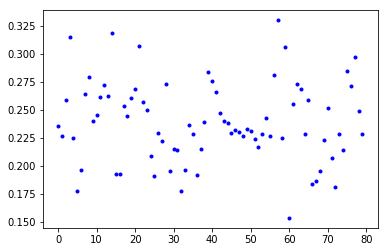

In [9]:
plot(buf,'b.')

In [10]:
buf

array([0.23603507, 0.22718057, 0.25882904, 0.31549003, 0.22509292,
       0.17762675, 0.19661191, 0.26403835, 0.27908381, 0.24013838,
       0.24517753, 0.2618329 , 0.27218606, 0.26221247, 0.31912214,
       0.19305833, 0.19297325, 0.25384225, 0.24491576, 0.26079235,
       0.26849505, 0.30709363, 0.25742855, 0.24969968, 0.20901345,
       0.19068273, 0.22982449, 0.22208906, 0.27316772, 0.19568261,
       0.21478557, 0.21395444, 0.1773388 , 0.19606218, 0.23617905,
       0.22863996, 0.19193924, 0.21546618, 0.23893422, 0.28423421,
       0.27553023, 0.26636814, 0.24755313, 0.24038707, 0.23863972,
       0.2296347 , 0.23206265, 0.22995537, 0.22657194, 0.23263856,
       0.23097629, 0.2244254 , 0.21714153, 0.22824075, 0.24307679,
       0.22710204, 0.28080497, 0.33017555, 0.22468717, 0.30641301,
       0.153537  , 0.2552951 , 0.27357347, 0.26859322, 0.22881666,
       0.25874397, 0.18358865, 0.18640272, 0.19574805, 0.22293328,
       0.25142084, 0.20674911, 0.18087929, 0.22845017, 0.21386

In [8]:
np.sum(buf)

66.75933379016935

In [32]:
np.savetxt('20220628_30uA.dat',buf)

In [33]:
%pwd

'/net/nfs/srv/OPI/dimtel/darcs/bbfb/ipynb3/Li'

In [10]:
temp1 = epics.PV('JLC15VP')

In [11]:
buf[45]

-0.015889681943229025

In [ ]:
while 1:
    buf = MBfilling.get()
    temp1.put(buf[37])
    time.sleep(0.5)

In [13]:
flag = epics.PV('JLC16VP')

In [11]:
photondiode = epics.PV('mlsCurrent:Mnt3collectData.VALD')

In [12]:
photondiode.get()

2597.58576

In [15]:
date_time =  datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
print(date_time)

flag.put(1)

MBfile ="/srv/mdidata/SSMB/data/current/MBcurrent_"+date_time+".dat"
print(MBfile)
with open(MBfile,"w+") as f:
    
    while flag.get():
        N =5
        A = np.zeros((N,82))
        for i in range(N):
            A[i,0] = time.time()
            A[i,1:81] = MBfilling.get()
            A[i,81] = photondiode.get()
            time.sleep(0.5)
        #print(A)
        B = np.mean(A,axis=0).reshape((1,-1))
        print(B.shape)
        f.write("\n".join(" ".join(map(str, ele)) for ele in B))
        f.write('\n')
        f.flush()
f.close()

2022-11-03_15-12-17
/opt/OPI/MachinePhysics/MachineDevelopment/li/commissioning/MBcurrent_2022-11-03_15-12-17_background.dat
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)
(1, 82)


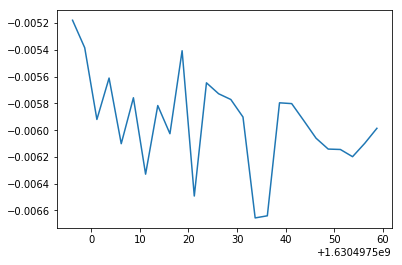

In [16]:
rdout = np.loadtxt('/opt/OPI/MachinePhysics/MachineDevelopment/li/commissioning/MBcurrent2021_09_01_13:58:15background.dat')
plot(rdout[:,0],rdout[:,-1])

In [18]:
42.5/16

2.65625

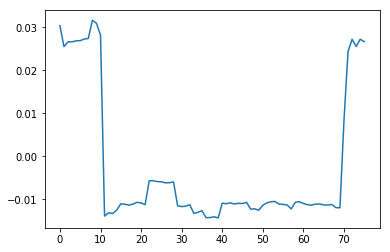

In [32]:
plot(rdout[0,5::])

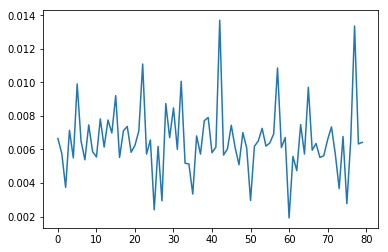

[ 0.00664906  0.00576557  0.00373682  0.00713989  0.00549725  0.0099016
  0.00650508  0.00537946  0.00746056  0.00587028  0.00554961  0.0078205
  0.00614514  0.00775505  0.00698282  0.0092079   0.00552343  0.00711371
  0.00736894  0.00583102  0.00624985  0.00710062  0.01109267  0.00572631
  0.00656398  0.00240178  0.00618441  0.00293841  0.00873671  0.00670141
  0.00847493  0.00600117  0.01006521  0.00518313  0.00513077  0.00333762
  0.00680612  0.00571976  0.00771579  0.00790557  0.00580484  0.0061386
  0.01370387  0.00566741  0.00603389  0.00744093  0.00610588  0.0050915
  0.00700245  0.00608625  0.00295805  0.00619096  0.00649854  0.00725768
  0.0061975   0.00638729  0.00692392  0.01085708  0.00611242  0.0067145
  0.00191749  0.00558233  0.00473811  0.00748019  0.00572631  0.00970527
  0.00595536  0.00635456  0.00552343  0.0056216   0.00657707  0.00734276
  0.00571976  0.00367138  0.0067734   0.00276826  0.00653781  0.01335702
  0.00632839  0.00642655]


In [14]:
ref = MBfilling.get()
plt.plot(ref)
plt.show()
print(ref)
np.savetxt('SBcurrents20190621-5.txt',ref)

[  2.81407053e-04   2.74862702e-04   1.17798301e-04   3.07584453e-04
   1.30887001e-04   5.17003655e-04   1.89786152e-04   4.58104504e-04
   3.01040103e-04  -1.76697452e-04   2.02874852e-04   4.64648854e-04
   1.09290646e-03   3.27217503e-05  -2.81407053e-04  -7.19878506e-05
   2.35596602e-04   3.53394903e-04   4.38471454e-04   7.19878506e-04
   4.97370604e-04   1.63608751e-04   1.04709601e-04   2.48685302e-04
   6.28257606e-04  -2.15963552e-04   9.22753358e-04   7.06789806e-04
  -7.65688957e-04   1.09945081e-03  -1.50520051e-04   3.14128803e-04
   3.27217503e-04  -5.17003655e-04   1.89786152e-04  -2.74862702e-04
   2.55229652e-04   5.95535855e-04   6.34801956e-04   7.19878506e-05
   3.73027953e-04   2.15963552e-04   8.44221158e-04   1.76697452e-04
   2.22507902e-04  -1.83241802e-04   5.36636705e-04  -9.81652509e-05
   4.38471454e-04   4.64648854e-04   3.27217503e-04  -4.18838404e-04
   4.05749704e-04  -1.96330502e-05  -2.81407053e-04  -3.66483603e-04
   1.04709601e-03   5.49725405e-04

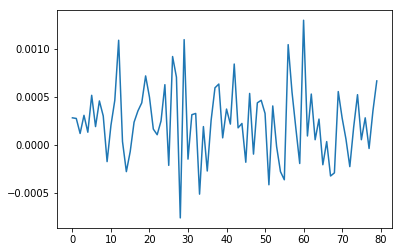

In [4]:
newfilling = MBfilling.get() -ref
print(newfilling)
plt.plot(newfilling)
plt.show()

In [65]:
newfilling[0]

0.0010274629592600271

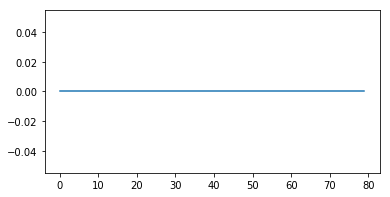

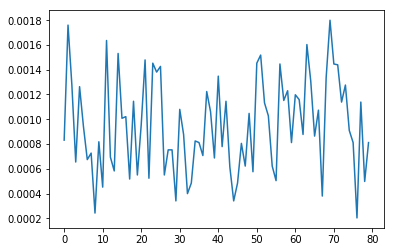

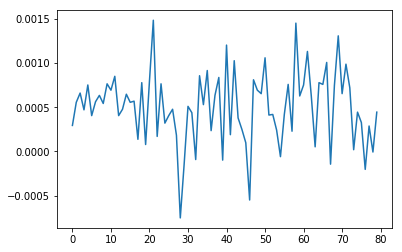

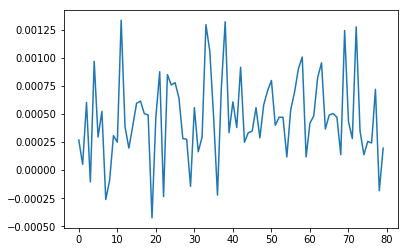

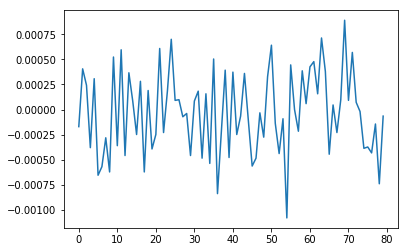

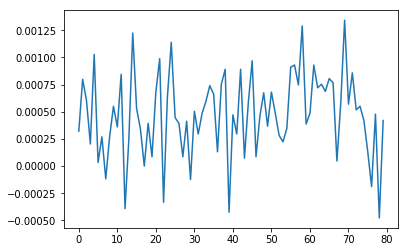

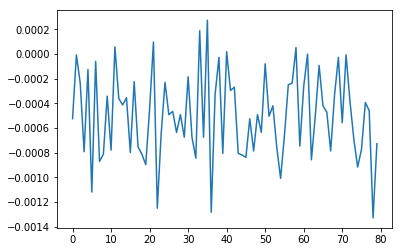

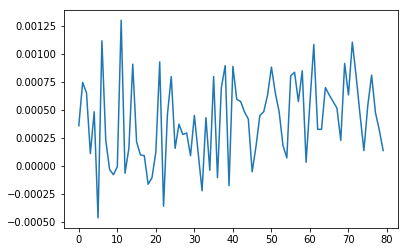

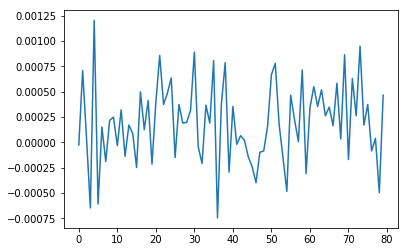

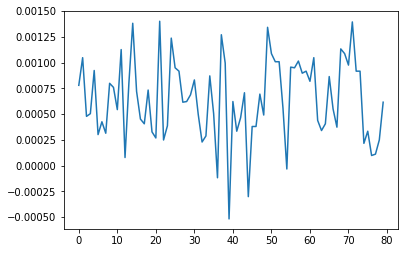

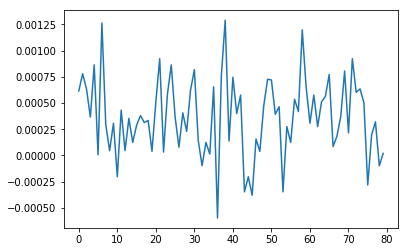

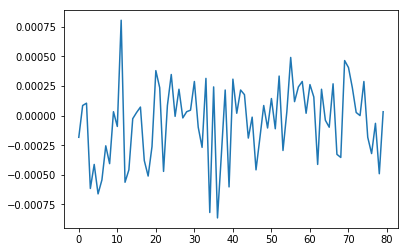

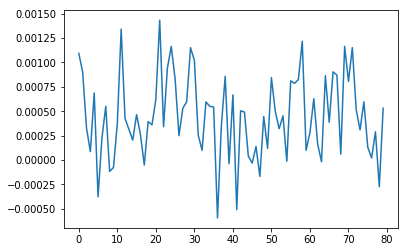

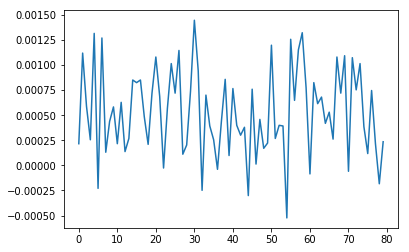

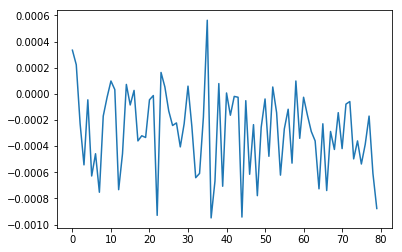

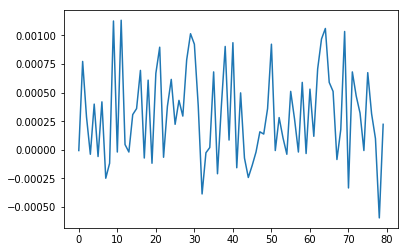

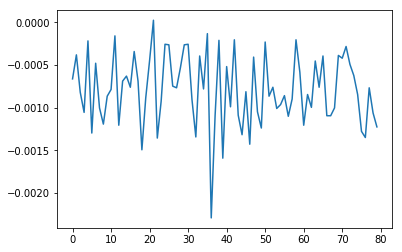

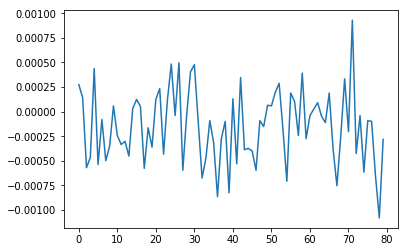

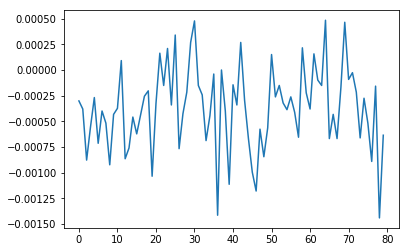

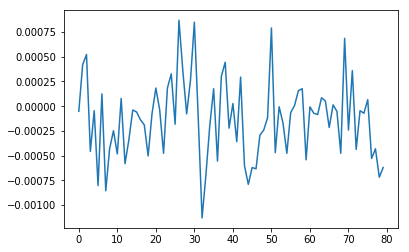

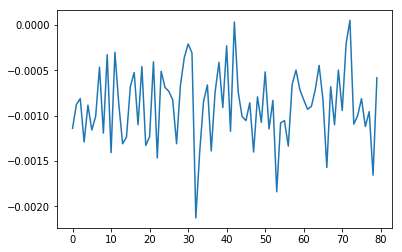

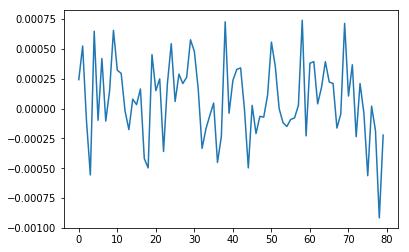

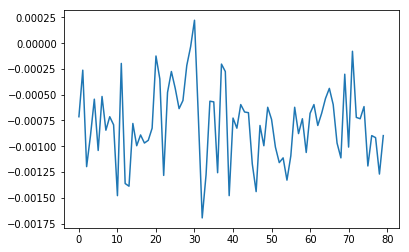

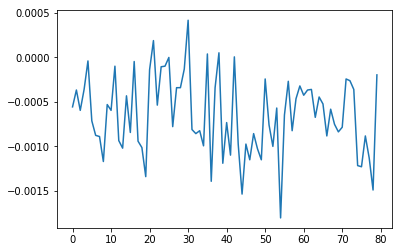

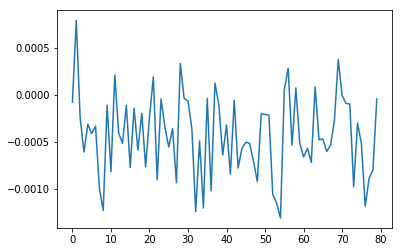

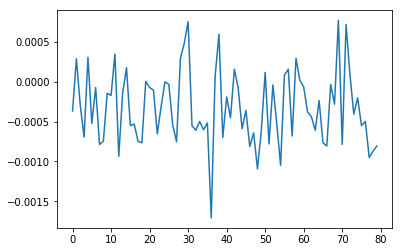

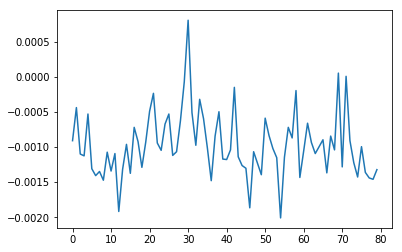

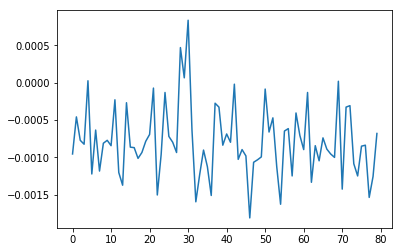

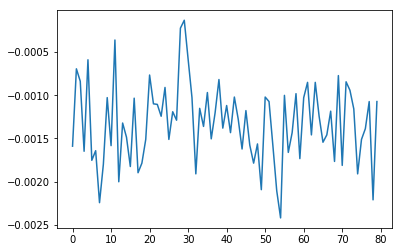

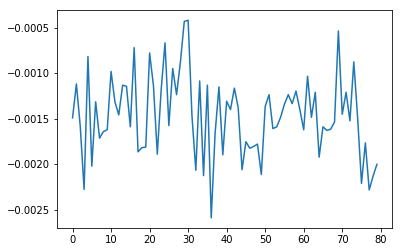

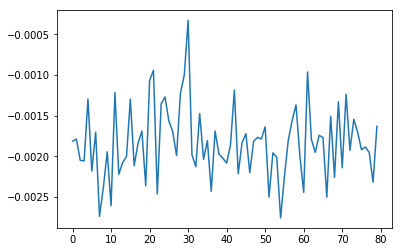

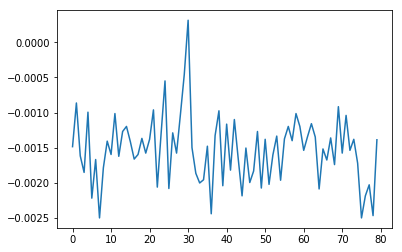

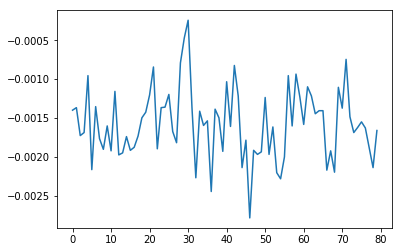

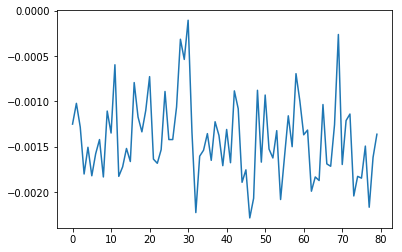

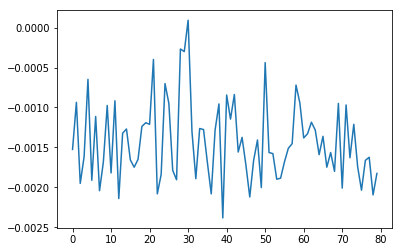

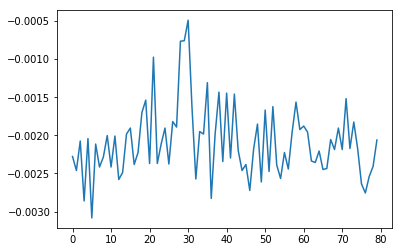

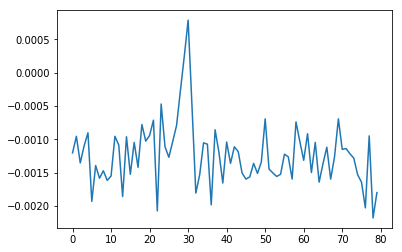

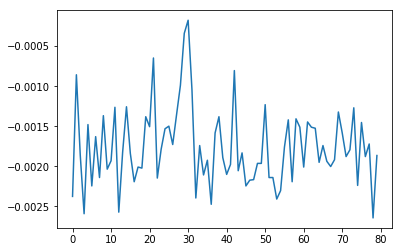

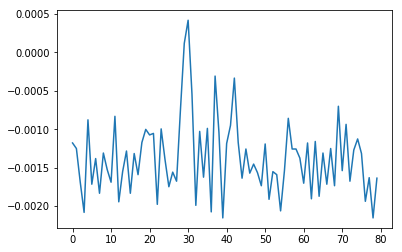

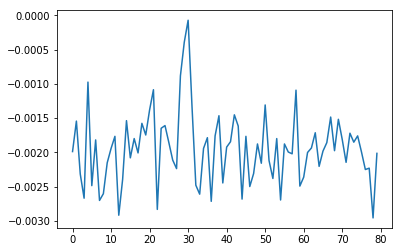

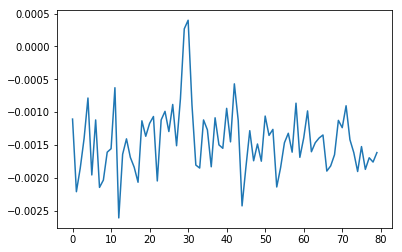

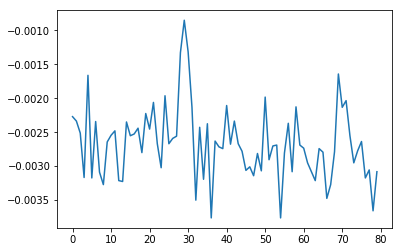

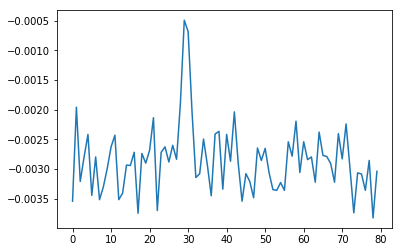

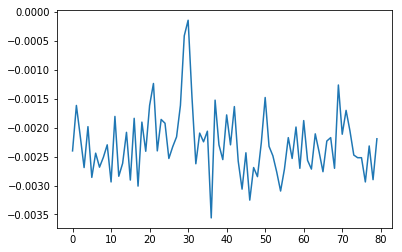

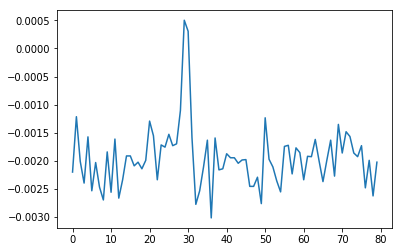

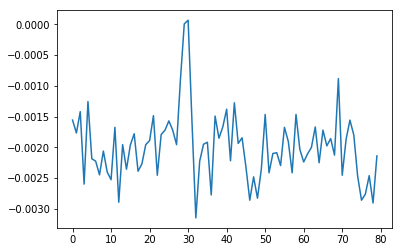

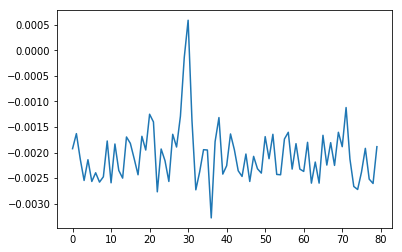

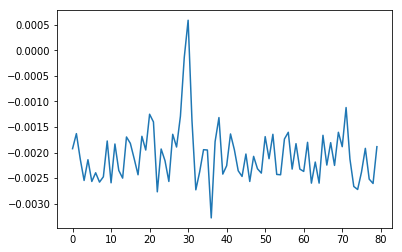

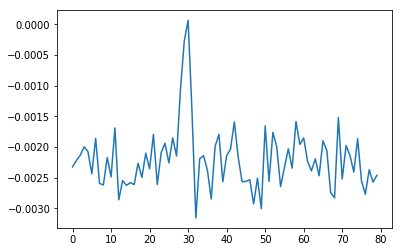

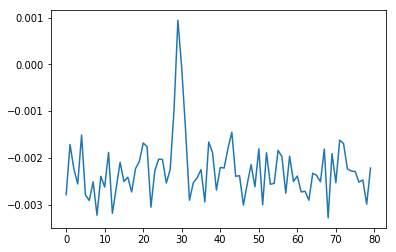

In [60]:
N = 50
MBdata = np.zeros((N,80))
ref = MBfilling.get()

fig = plt.figure(figsize=(6, 3))




for i in range(N):
    newfilling = MBfilling.get() -ref
    MBdata[i,:] = newfilling
    plt.plot(newfilling)
    fig.savefig(str(i)+'.png')
    plt.show()
    time.sleep(5)

AttributeError: module 'matplotlib.pyplot' has no attribute 'on'

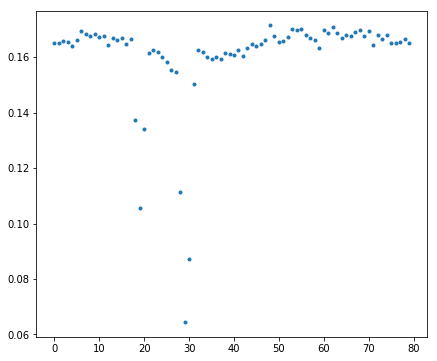

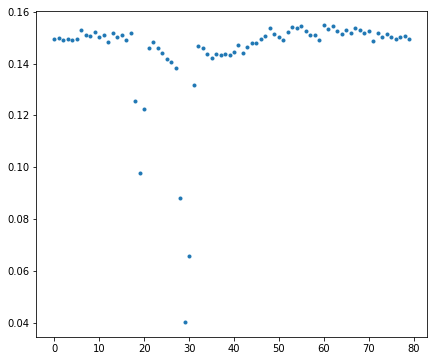

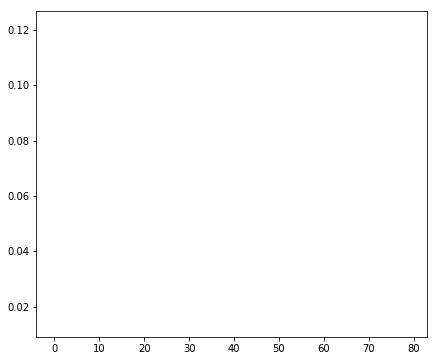

In [58]:
ref = MBfilling.get()
class DataViewer(object):
    def __init__(self):
        self.buf = 0
        
    def init(self):
        fig,ax = plt.subplots(1,1,figsize=(7,6))

        self.plt1, = ax.plot(range(80),ref,'.')
        self.ax =  ax
        return fig
    
    def animate(self,i):
        
        time.sleep(5)
        self.plt1.set_ydata(MBfilling.get() - ref)

viewer = DataViewer()
fig = viewer.init()
ani = animation.FuncAnimation(fig,viewer.animate, frames = np.arange(0,150),interval = 1500)

#ani.save('laserscan.mp4',dpi=300, writer = writer)
plt.show()
    
    

